# <a href="https://thetahat.ru/courses/ad" target="_top">Введение в анализ данных</a>
## Домашнее задание 6. Основы обработки текстов


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="https://miptstats.github.io/theta_grader_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.

**Баллы за задание:**

* Задача 1 &mdash; 100 баллов
* Задача 2 &mdash; 50 баллов

Баллы учитываются в <b><font color="green">факультативной части</font></b> курса и не влияют на оценку по основной части.

In [ ]:
# Bot check

# HW_ID: fpmi_ad6
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

Перед выполнением задания **обязательно посмотрите** <a href="https://thetahat.ru/files/ad/main/6/lec6.pdf" target="_blank" rel="noopener noreferrer">презентацию</a>, <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part1" target="_top">ноутбук</a> по RNN и <a href="https://thetahat.ru/courses/ad/main/6/nlp_sem_part2" target="_top">ноутбук</a> по LLM.

---
### Задача 2. Использование LLM.

In [ ]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 19.2 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.2
    Uninstalling fsspec-2025.3.2:
      Successfully uninstalled fsspec-2025.3.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system 

In [ ]:
import re
import time
from collections import Counter, OrderedDict
from string import punctuation
from typing import List

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import clear_output
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader, Dataset

import transformers

from datasets import load_dataset
from datasets import Dataset, load_dataset
from enum import Enum
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoProcessor

from pprint import pprint
from pydantic import BaseModel

print(transformers.__version__)
print(torch.__version__)

nltk.download("stopwords")
sns.set(style="whitegrid", palette="Set2")

device = (
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
)

4.50.3
2.6.0+cu124


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
assert torch.cuda.is_available(), "для этой части понадобится GPU"

Дисклеймер: *использовать LLM в рамках ограничений Colab хоть и возможно, но на первых порах может быть трудно.*

> Так как процесс генерации очень хрупкий и может сломаться, мы настоятельно рекомендуем **сохранить результаты предыдущей задачи в отдельном файле** и приступать к этой задаче в самом конце. Решения задач можно сдавать в бот разными файлами.

> Если у вас возникла ошибка `Out of memory`, перезапустите ноутбук и попробуйте снова. Да, языковые модели без своей GPU &mdash; это тяжело...

В рамках семинара мы реализовали модель на основе RNN для задачи анализа тональности текста, обучив её на датасете отзывов IMDB и добившись неплохих результатов. Затем мы посмотрели на пример использования LLM, таких как `Qwen-2.5-3B`, для решения той же задачи. В этой задаче вам предложено провести расширенное сравнительное исследование, оценив эффективность нескольких LLM в различных форматах: zero-/few-shot.

---
**Форматы zero-/few-shot**

Современные большие языковые модели (LLM), обученные следовать инструкциям, позволяют решать задачи классификации, если правильно оформить запрос к ним. Подготовку надежной инструкции для решения задачи иногда еще называют промптингом. Подробнее можно почитать <a href="https://docs.mistral.ai/guides/prompting_capabilities/" target="_top">здесь</a> или <a href="https://huggingface.co/docs/transformers//tasks/prompting" target="_top">здесь</a>, или самостоятельно обсудить с LLM!


Рассмотрим два довольно популярных подхода.
* *Zero-Shot* \
  Модель выполняет задачу, опираясь только на инструкцию, без дополнительных примеров. Допустим вы можете сформулировать запрос к модели так:
  ```
  Определи, POSITIVE или NEGATIVE тон у этого текста: {текст}.
  ```
  <br>
* *Few-Shot* \
  Модель получает $k$ **примеров вместе с ответом** перед основным запросом. Это позволяет познакомить модель, например, с форматом ответа и показать какие-то паттерны через демонстрацию. \
  Рассмотрим возможный `2-shot` формат. Он предполагает демонстрацию на **двух примерах вместе с референсным ответом**. Третьим запросом будет идти целевой:

  ```
  Пример 1: "Фильм ужасен..." → NEGATIVE
  Пример 2: "Это шедевр!" → POSITIVE
  Задача: Определи тональность для "{текст}".
  ```

Обратим внимание, что Few-Shot-подход можно реализовать разными способами в зависимости от API или чат-интерфейса модели.

1. Использовать системный промпт и указать инструкцию вместе с примерами прямо там.

```
system_prompt = """
Ты классифицируешь тональность текста. Вот примеры:  
- "Фильм ужасен..."\nОтвет: NEGATIVE  
- "Это шедевр!"\nОтвет: POSITIVE  
Отвечай только метками POSITIVE/NEGATIVE.  
"""
```

В таком случае в `user`-реплике будет содержаться только текст целевого отзыва. При этом можно поступить иначе и использовать, например, стандартный системный промпт, рекомендованный разработчиками модели. Тогда инструкцию и few-shot примеры можно поместить сразу в `user`-реплику.


2. Используя чат-шаблон (chat-template). Тогда k-shot вариант можно реализовать следующим образом:

```
{"role": "system", "content": "Ты классифицируешь тональность текста."},  # Общая инструкция в сис. промпте, но можно и в user-реплику!
{"role": "user", "content": "Отзыв: 'Сюжет скучный...'\nОтвет:"},         # Пример 1
{"role": "assistant", "content": "NEGATIVE"},                             # Важно: ответ модели заполнен нами самостоятельно! Его можно взять из train-сета
...
{"role": "user", "content": "Отзыв: 'Лучший фильм года!'\nОтвет:"},       # Пример k
{"role": "assistant", "content": "POSITIVE"},                             # Ответ для примера k
{"role": "user", "content": "Отзыв: '{review}'\nОтвет:"}                  # Тут расположен целевой пример для прогона
```
В данном случае $k$ примеров, которые можно взять из обучающей выборки, вместе с ответами и примером для инференса принудительно помещены в историю диалога. Модель, генерируя след. реплику, выдаст нам ответ на задачу, а примеры в контексте позволят лучше следовать формату ответа и потенциально повысят итоговое качество.

Выбор стратегии, вообще говоря, зависит от пользователя и ограничений модели. Например, некоторые модели могут не поддерживать системный промпт.

---

Итак, вам требуется применить **две** open-source LLM для задачи sentiment analysis с семинара и сравнить их производительность в режимах zero- и few-shot на **валидационной выборке**. Для few-shot используйте $k=5$ примеров, которые возьмите случайным образом из обучающей выборки. Это факультативная часть курса, поэтому выбор конкретного формата, из описанных выше, остается на вашей стороне :)


**Подумайте**, должны ли few-shot примеры быть сбалансированы, то есть содержать приблизительно одинаковое кол-во позитивных и негативных примеров?

В качестве LLM используйте `Qwen/Qwen2.5-3B` и `unsloth/Llama-3.2-1B-Instruct` с HuggingFace. Попробуйте **поэкспериментировать с различными вариантами промпта**. Можете взять за основу пример с семинара и воспользоваться ИИ-инструментами для его усовершенствования. Сравните результат с моделью на базе RNN, полученной на семинаре.

Представьте результат в виде аккуратной таблицы, в которой укажите модель вместе с используемым форматом (zero-/few-shot), а также итоговую точность (accuracy). Сделайте выводы.

Загрузим IMDb

In [ ]:
data = load_dataset("scikit-learn/imdb", split="train").train_test_split(test_size=0.2, seed=42)

train_dataset, test_dataset = data["train"], data["test"]

# train_dataset = list(train_iter)
# test_dataset = list(test_iter)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Взятие подвыборки из 2000 образцов
train_dataset = train_dataset.select(range(2000))

Оставим только нужные столбцы

In [ ]:
# Удаление ненужных столбцов
train_dataset = train_dataset.remove_columns([col for col in train_dataset.column_names if col not in ["review", "sentiment"]])
test_dataset = test_dataset.remove_columns([col for col in test_dataset.column_names if col not in ["review", "sentiment"]])

# Проверка оставшихся столбцов
print(train_dataset.column_names)
print(test_dataset.column_names)

['review', 'sentiment']
['review', 'sentiment']


Посмотрим на несколько примеров текстов.

In [ ]:
for i in range(4):
    print("Review:", train_dataset[i]["review"])
    print("Sentiment:", train_dataset[i]["sentiment"])
    print()

Review: The film disappointed me for many reasons: first of all the depiction of a future which seemed at first realistic to me was well-built but did only feature a marginal role. Then, the story itself was a weak copy of Lost in Translation. The Middle-Eastern setting, man with family meets new girl overseas, karaoke bar, the camera movements and the imagery - all that was a very bad imitation of the excellent Lost in Translation which had also credibility. This movie tries to be something brilliant and cultural: it is not. I wonder why Tim Robbins even considered doing this film!? The female main actress is awful - did she play the precog in Minority Report? And why do you have to show the vagina in a movie like this? Lost in Translation didn't have to show excessive love scenes. R-Rated just for this? This movie isn't even worth watching it from a videostore!
Sentiment: negative

Review: Can this "film" be considered as a film? Imagine the situation: somebody puts a handy cam over 

Теперь загрузи модельки с токенизаторами

In [ ]:
# Загрузка токенизаторов и моделей
tokenizer_qwen = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B")
model_qwen = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-3B", torch_dtype="auto", device_map="auto")

tokenizer_llama = AutoTokenizer.from_pretrained("unsloth/Llama-3.2-1B-Instruct")
model_llama = AutoModelForCausalLM.from_pretrained("unsloth/Llama-3.2-1B-Instruct", torch_dtype="auto", device_map="auto")

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Токенизируем данные

In [ ]:
def tokenize_function_qwen(examples):
    return tokenizer_qwen(examples["review"], padding="max_length", truncation=True)

def tokenize_function_llama(examples):
    return tokenizer_llama(examples["review"], padding="max_length", truncation=True)

# Параллельная токенизация с использованием num_proc
train_dataset_qwen = train_dataset.map(tokenize_function_qwen, batched=True, num_proc=4)
val_dataset_qwen = test_dataset.map(tokenize_function_qwen, batched=True, num_proc=4)

train_dataset_llama = train_dataset.map(tokenize_function_llama, batched=True, num_proc=4)
val_dataset_llama = test_dataset.map(tokenize_function_llama, batched=True, num_proc=4)

Map (num_proc=4):   0%|          | 0/2000 [00:00<?, ? examples/s]

RuntimeError: One of the subprocesses has abruptly died during map operation.To debug the error, disable multiprocessing.

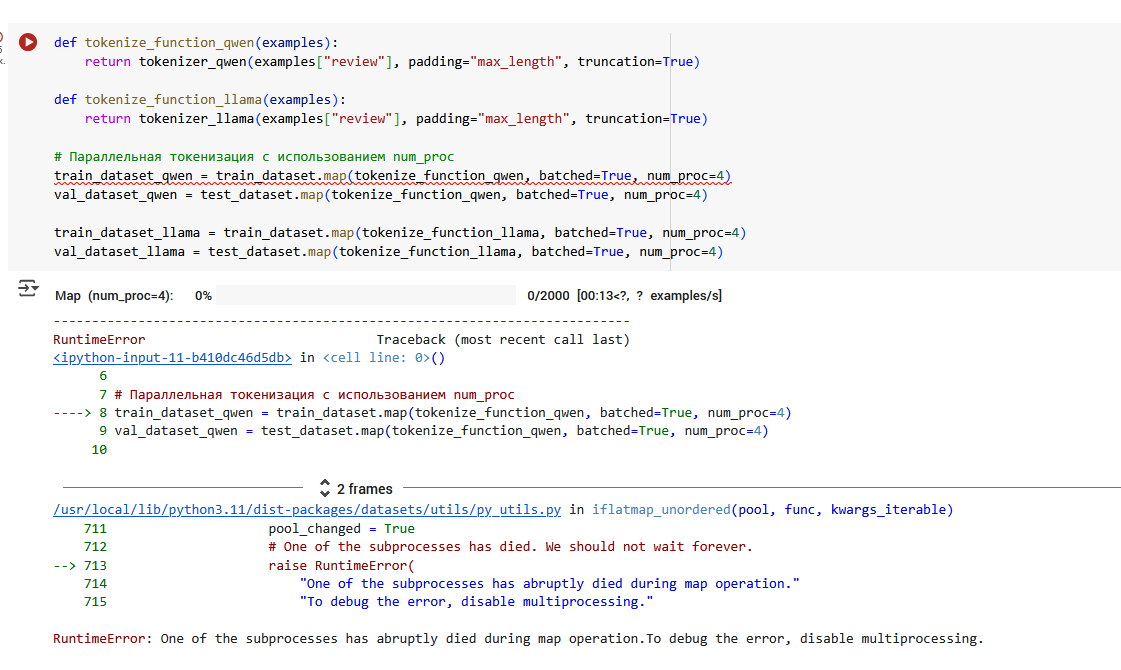

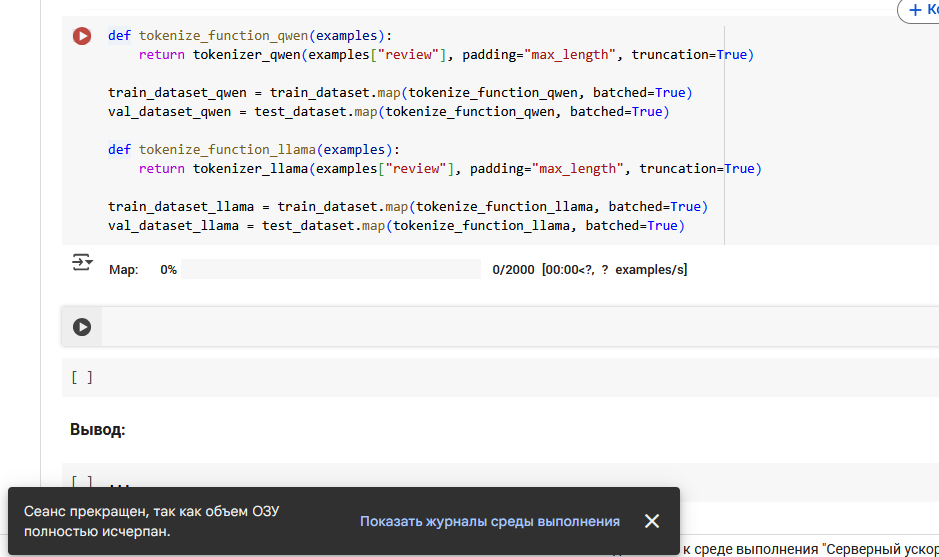

Сделаем тогда так:

In [5]:
!pip install vllm

In [6]:
from vllm import LLM, SamplingParams
from vllm.sampling_params import GuidedDecodingParams

In [7]:
model_qwen = LLM(model="Qwen/Qwen2.5-3B", dtype="float16")
model_llama = LLM(model="unsloth/Llama-3.2-1B-Instruct", dtype="float16")

WARNING 04-13 16:46:19 [config.py:2704] Casting torch.bfloat16 to torch.float16.
INFO 04-13 16:46:19 [config.py:600] This model supports multiple tasks: {'generate', 'reward', 'embed', 'classify', 'score'}. Defaulting to 'generate'.
INFO 04-13 16:46:19 [llm_engine.py:242] Initializing a V0 LLM engine (v0.8.3) with config: model='Qwen/Qwen2.5-3B', speculative_config=None, tokenizer='Qwen/Qwen2.5-3B', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, override_neuron_config=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.float16, max_seq_len=32768, download_dir=None, load_format=LoadFormat.AUTO, tensor_parallel_size=1, pipeline_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, kv_cache_dtype=auto,  device_config=cuda, decoding_config=DecodingConfig(guided_decoding_backend='xgrammar', reasoning_backend=None), observability_config=ObservabilityConfig(show_hidden_metrics=False, otlp_traces_endpoint=None, collect_model_f

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


INFO 04-13 16:46:59 [loader.py:447] Loading weights took 38.32 seconds
INFO 04-13 16:46:59 [model_runner.py:1146] Model loading took 5.7838 GiB and 38.656788 seconds


OutOfMemoryError: CUDA out of memory. Tried to allocate 128.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 84.12 MiB is free. Process 223805 has 14.66 GiB memory in use. Of the allocated memory 14.32 GiB is allocated by PyTorch, and 194.86 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

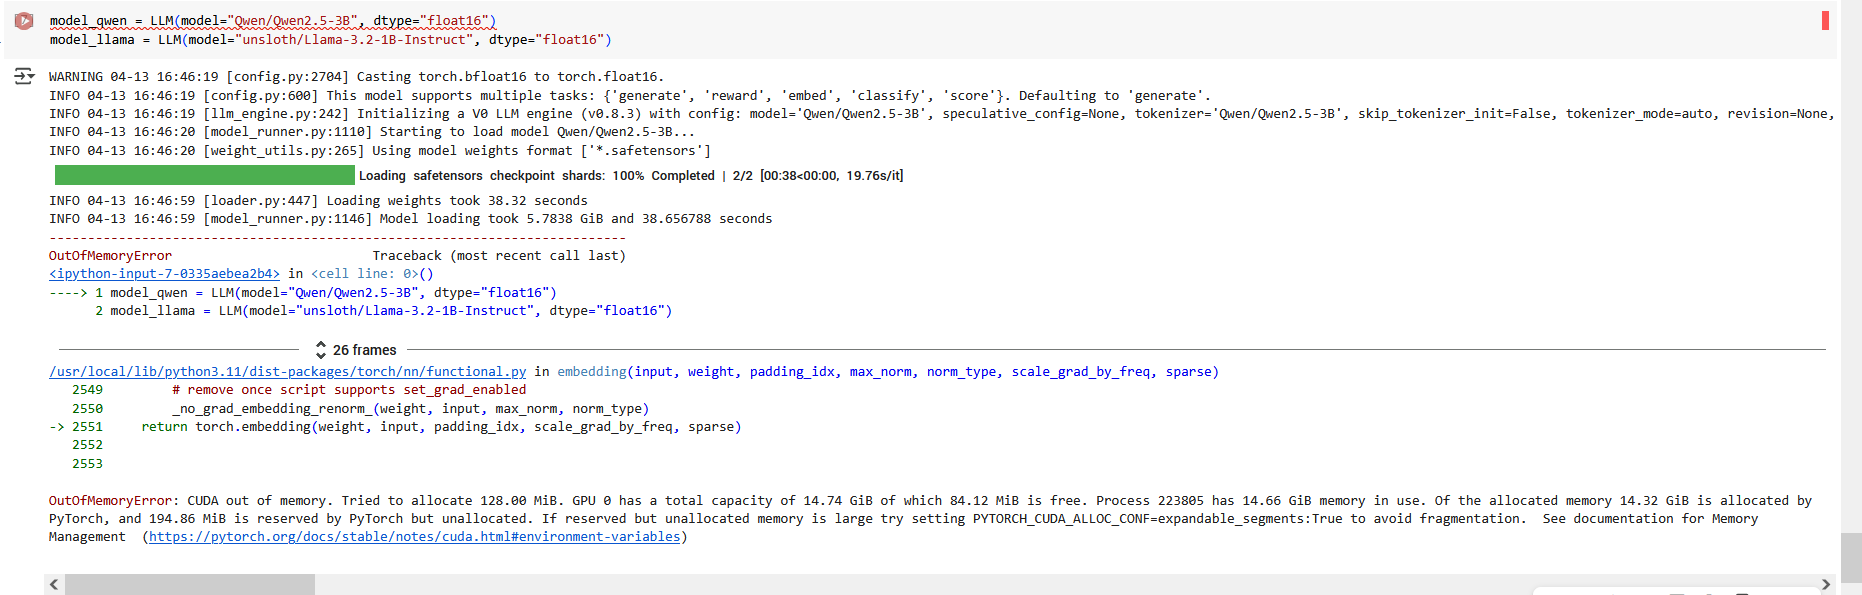

**Вывод:**

In [ ]:
...